## Proyecto final - Predicción de casos de dengue mediante modelos de aprendizaje supervisado (2022–2024)

### Integrantes:
Jeferson Flórez Cantillo <br> 
Luis David Pérez Flórez <br> 
Juan David Andrades Sanabria <br> 


### I. Descripción del problema

El dengue es una enfermedad viral transmitida por el mosquito Aedes Aegypti y constituye uno de los problemas epidemiológicos más relevantes en Colombia. Su comportamiento no es uniforme: varía entre regiones, puede afectar más a ciertos grupos poblacionales, cambia por temporalidad, ciclos, clima y estacionalidad. Por este motivo, antes de modelar, se realizará un análisis descriptivo (EDA) para identificar qué grupos poblacionales y qué zonas del país presentan mayor incidencia, respondiendo preguntas como:

- ¿A quién afecta más el dengue: hombres o mujeres?

- ¿Existe un rango de edad más afectado?

- ¿Cuáles son los departamentos o zonas del país con mayor recurrencia?

- ¿Cómo se distribuye el dengue a lo largo del tiempo en los años 2022-2024?

Este análisis EDA permitirá justificar qué variables realmente aportan información útil para predicción.

Posteriormente, con base en el análisis exploratorio, se seleccionarán y transformarán las variables adecuadas para convertir el problema de ocurrencia del dengue en un problema de regresión supervisada en series temporales, utilizando como variable objetivo la cantidad de casos confirmados.

El objetivo principal de este trabajo es utilizar datos históricos reales de dengue correspondientes a los años 2022, 2023 y 2024, para entrenar modelos supervisados de Machine Learning que permitan proyectar cómo sería el comportamiento del dengue en Colombia en la siguiente ventana temporal futura.

Modelos utilizados

Para cumplir el objetivo, se implementarán y compararán los siguientes modelos supervisados:

- Regresión multivariada

- Árbol de decisión

- Random Forest

- Redes neuronales (MLP / DNN)

Cada modelo será evaluado utilizando técnicas de ajuste de hiperparámetros con GridSearchCV, y se compararán métricas de desempeño como MAE, MSE y R² para determinar cuál método ofrece la mejor capacidad predictiva para el comportamiento temporal del dengue nacional.

#### Librerias utilizadas

In [1]:
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import seaborn as sns
import matplotlib.pyplot as plt


#### Cargando el Dataset 

El dataset original proviene de datos de vigilancia del sistema colombiano (años 2022-2024). Contiene múltiples columnas clínicas, administrativas, geográficas y epidemiológicas. Durante la inspección se identificó que muchas variables no son necesarias para el objetivo predicitivo planteado, por lo tanto, se realizará un proceso de limpieza y selección de variables.

In [2]:
df = pd.read_excel("Datos_22-24.xlsx", sheet_name="22-24", engine="openpyxl")

print("Filas y columnas:", df.shape)
df.head(10)

Filas y columnas: (501729, 73)


,CONSECUTIVE,COD_EVE,FEC_NOT,SEMANA,ANO,COD_PRE,COD_SUB,EDAD,UNI_MED,nacionalidad,...,Nom_upgd,Pais_ocurrencia,Nombre_evento,Departamento_ocurrencia,Municipio_ocurrencia,Pais_residencia,Departamento_residencia,Municipio_residencia,Departamento_Notificacion,Municipio_notificacion
0,8915475,210,2022-09-30,39,2022,8541000080,1,19,1,170,...,ESE HOSPITAL LOCAL DE TAURAMENA,COLOMBIA,DENGUE,CASANARE,TAURAMENA,COLOMBIA,CASANARE,TAURAMENA,CASANARE,TAURAMENA
1,8915476,210,2022-02-07,5,2022,8501000190,1,18,1,170,...,HOSPITAL DE AGUAZUL JUAN HERNANDO URREGO ESE,COLOMBIA,DENGUE,CASANARE,AGUAZUL,COLOMBIA,CASANARE,AGUAZUL,CASANARE,AGUAZUL
2,8915477,210,2022-04-08,13,2022,8500100001,3,19,1,170,...,HOSPITAL DE YOPAL ESE NUEVA SEDE,COLOMBIA,DENGUE,CASANARE,TAURAMENA,COLOMBIA,CASANARE,TAURAMENA,CASANARE,YOPAL
3,8908033,210,2022-04-04,13,2022,8500100001,3,8,1,170,...,HOSPITAL DE YOPAL ESE NUEVA SEDE,COLOMBIA,DENGUE,CASANARE,YOPAL,COLOMBIA,CASANARE,YOPAL,CASANARE,YOPAL
4,8908034,210,2022-05-16,19,2022,5000600169,1,8,1,170,...,HOSPITAL MUNICIPAL DE ACACIAS,COLOMBIA,DENGUE,META,ACACIAS,COLOMBIA,META,ACACIAS,META,ACACIAS
5,8908035,210,2022-07-16,28,2022,5031300522,1,8,1,170,...,HOSPITAL DEPARTAMENTAL DE GRANADA ESE,COLOMBIA,DENGUE,META,GRANADA,COLOMBIA,META,GRANADA,META,GRANADA
6,8908036,210,2022-05-15,19,2022,5031300522,1,8,1,170,...,HOSPITAL DEPARTAMENTAL DE GRANADA ESE,COLOMBIA,DENGUE,META,GRANADA,COLOMBIA,META,GRANADA,META,GRANADA
7,8908037,210,2022-08-21,33,2022,5031300115,8,8,1,170,...,SERVIMEDICOS SAS,COLOMBIA,DENGUE,META,GRANADA,COLOMBIA,META,GRANADA,META,GRANADA
8,8908038,210,2022-11-03,43,2022,5031300522,1,8,1,170,...,HOSPITAL DEPARTAMENTAL DE GRANADA ESE,COLOMBIA,DENGUE,META,GRANADA,COLOMBIA,META,GRANADA,META,GRANADA
9,8908039,210,2022-04-11,14,2022,8500100001,3,11,1,170,...,HOSPITAL DE YOPAL ESE NUEVA SEDE,COLOMBIA,DENGUE,CASANARE,YOPAL,COLOMBIA,CASANARE,YOPAL,CASANARE,YOPAL


### II. Análisis Exploratorio de Datos (EDA)

Para comprender el comportamiento del dengue en Colombia y caracterizar la población afectada, se realiza un análisis exploratorio de datos considerando aspectos demográficos y territoriales. El objetivo del EDA es identificar patrones y comportamientos relevantes para entender el fenómeno antes de aplicar los modelos supervisados.

Se analizan especialmente tres variables clave:

- SEXO: para evaluar si existe mayor afectación en hombres o mujeres.

- EDAD: para determinar qué rangos etarios presentan mayor frecuencia de casos.

- Departamento_ocurrencia: para identificar las zonas del país donde el dengue se presenta con mayor incidencia.

Este EDA permite contextualizar el fenómeno epidemiológico y da soporte a las decisiones posteriores de selección de características y construcción del modelo predictivo.


#### Información general del dataset

In [3]:
# Información general
print("Información general del dataset:")
df.info()
print("\nDescripción estadística general:")
display(df.describe(include='all'))


Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501729 entries, 0 to 501728
Data columns (total 73 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   CONSECUTIVE                501729 non-null  int64         
 1   COD_EVE                    501729 non-null  int64         
 2   FEC_NOT                    501729 non-null  datetime64[ns]
 3   SEMANA                     501729 non-null  int64         
 4   ANO                        501729 non-null  int64         
 5   COD_PRE                    501729 non-null  int64         
 6   COD_SUB                    501729 non-null  int64         
 7   EDAD                       501729 non-null  int64         
 8   UNI_MED                    501729 non-null  int64         
 9   nacionalidad               501729 non-null  int64         
 10  nombre_nacionalidad        501729 non-null  object        
 11  SEXO               

,CONSECUTIVE,COD_EVE,FEC_NOT,SEMANA,ANO,COD_PRE,COD_SUB,EDAD,UNI_MED,nacionalidad,...,Nom_upgd,Pais_ocurrencia,Nombre_evento,Departamento_ocurrencia,Municipio_ocurrencia,Pais_residencia,Departamento_residencia,Municipio_residencia,Departamento_Notificacion,Municipio_notificacion
count,5.017290e+05,501729.0,501729,501729.000000,501729.000000,5.017290e+05,501729.000000,501729.000000,501729.000000,501729.000000,...,498670,501729,501729,501729,501729,501729,501729,501727,501729,501729
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3571,45,1,33,970,49,34,1014,33,870
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,FUNDACION CLINICA INFANTIL CLUB NOEL,COLOMBIA,DENGUE,VALLE,CALI,COLOMBIA,VALLE,CALI,VALLE,CALI
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6628,500760,501729,116309,51550,500974,116013,52362,117121,58203
mean,1.074094e+07,210.0,2023-12-30 09:53:22.078413056,26.333979,2023.486191,5.166173e+09,4.860502,23.458742,1.015211,183.148546,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,8.908033e+06,210.0,2022-01-02 00:00:00,1.000000,2022.000000,5.001000e+08,0.000000,1.000000,1.000000,4.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1.030206e+07,210.0,2023-08-12 00:00:00,15.000000,2023.000000,2.318201e+09,1.000000,10.000000,1.000000,170.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.096060e+07,210.0,2024-03-16 00:00:00,25.000000,2024.000000,6.600102e+09,1.000000,17.000000,1.000000,170.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.131224e+07,210.0,2024-07-02 00:00:00,38.000000,2024.000000,7.600103e+09,2.000000,32.000000,1.000000,170.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,1.174764e+07,210.0,2025-03-29 00:00:00,52.000000,2024.000000,9.977384e+09,99.000000,122.000000,4.000000,862.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Distribución por sexo

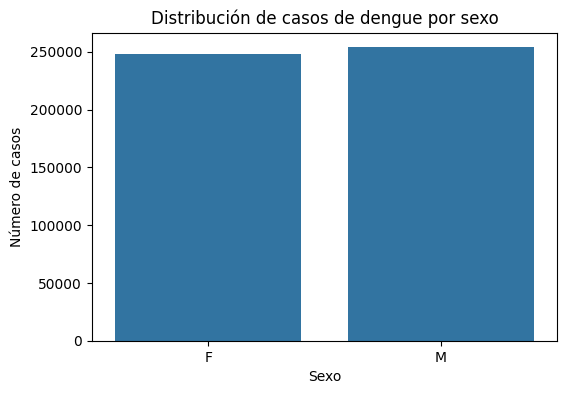

In [ ]:
# Distribución por sexo
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="SEXO")
plt.title("Distribución de casos de dengue por sexo")
plt.xlabel("Sexo")
plt.ylabel("Número de casos")
plt.show()

La distribución de casos de dengue por sexo muestra que la afectación entre hombres (M) y mujeres (F) es relativamente similar. No se evidencia una diferencia marcada de predominancia de un sexo sobre el otro, lo cual indica que la enfermedad no presenta una tendencia significativa por género en los registros analizados entre los años 2022 y 2024 en Colombia. Este patrón es consistente con literatura epidemiológica del dengue, donde el riesgo de infección está altamente correlacionado con exposición ambiental al vector y no con características biológicas específicas del sexo.

#### Distribución por edad

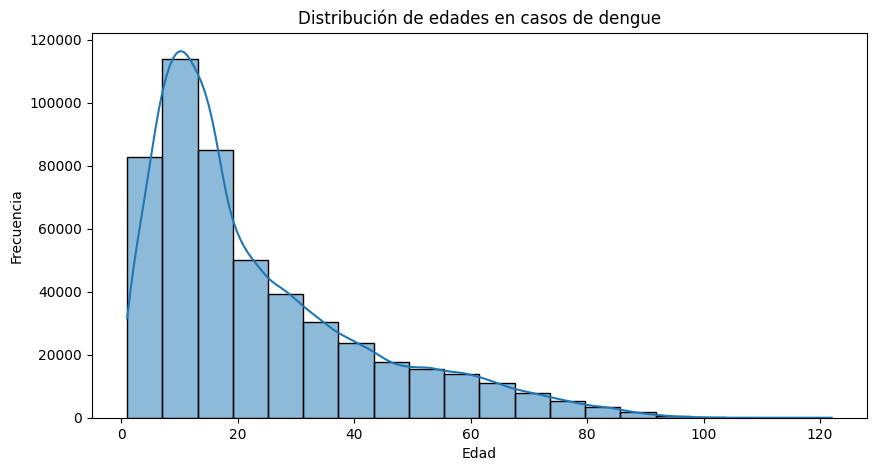

In [ ]:
# Distribución por edad
plt.figure(figsize=(10,5))
sns.histplot(df["EDAD"], bins=20, kde=True)
plt.title("Distribución de edades en casos de dengue")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

La distribución de edad de los casos reportados de dengue presenta una mayor concentración en población joven, especialmente entre aproximadamente 5 y 20 años. A medida que aumenta la edad, la frecuencia de casos disminuye progresivamente. Esto indica que la mayor carga de enfermedad se encuentra en población infantil, adolescente y adultos jóvenes, mientras que en población adulta mayor la incidencia es más baja. Este comportamiento es coherente con reportes epidemiológicos del dengue en Colombia, donde los menores tienen mayor exposición vectorial debido a contextos ambientales, escolares y comunitarios, especialmente en regiones endémicas.

Este patrón también indica que la edad, aunque es útil para caracterizar la población afectada, no necesariamente es una variable determinante para el modelo predictivo temporal nacional. Sin embargo, sí aporta evidencia de cómo se comporta el dengue en la población colombiana durante los años 2022-2024.

#### Top 10 departamentos con mayor número de casos

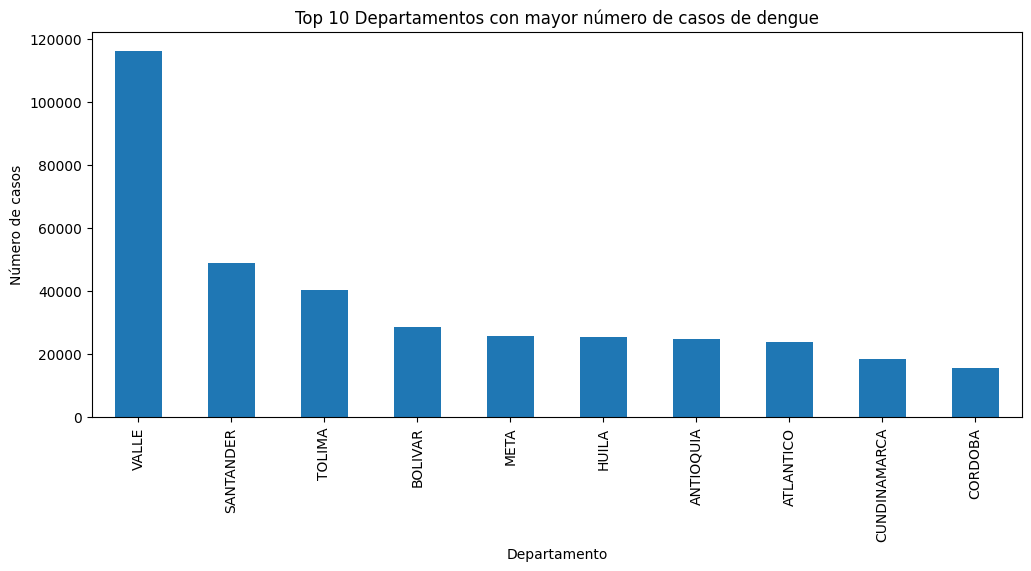

In [ ]:
# Top 10 Departamentos con más casos
plt.figure(figsize=(12,5))
df["Departamento_ocurrencia"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Departamentos con mayor número de casos de dengue")
plt.xlabel("Departamento")
plt.ylabel("Número de casos")
plt.show()

El análisis geográfico muestra que el mayor número de casos de dengue en Colombia se concentra principalmente en el departamento del Valle del Cauca, el cual presenta una carga significativamente superior respecto a los demás territorios. Posteriormente aparecen departamentos como Santander, Tolima, Bolívar, Meta, Huila, Antioquia, Atlántico, Cundinamarca y Córdoba.

Estos resultados indican que existe una alta concentración del dengue en regiones de clima cálido tropical y zonas con alta densidad poblacional, condiciones favorables para la reproducción del mosquito Aedes aegypti. Además, este patrón territorial sugiere que el dengue presenta una distribución geográfica heterogénea, siendo mucho más frecuente en ciertas zonas endémicas del país.

Este hallazgo respalda el concepto de que la ocurrencia del dengue no es homogénea a nivel nacional, sino que presenta focos de transmisión más intensa en departamentos específicos, lo cual debe tenerse en cuenta para interpretación epidemiológica del fenómeno.

#### Casos por año calendario (2022–2024)

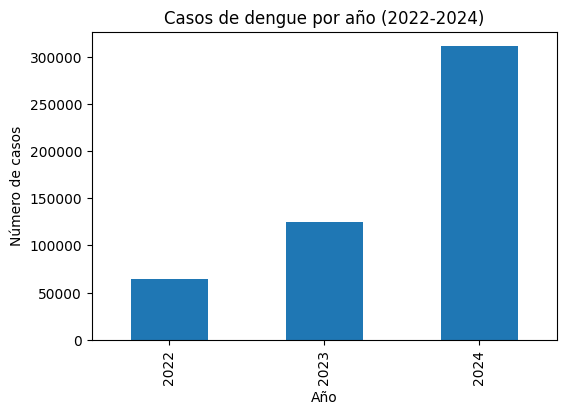

In [15]:
# Casos por año calendario
df["AÑO"] = pd.to_datetime(df["FEC_NOT"]).dt.year
df_filtrado = df[df["AÑO"].isin([2022, 2023, 2024])]
plt.figure(figsize=(6,4))
df_filtrado["AÑO"].value_counts().sort_index().plot(kind="bar")
plt.title("Casos de dengue por año (2022-2024)")
plt.xlabel("Año")
plt.ylabel("Número de casos")
plt.show()

#### Análisis temporal detallado (Serie semanal 2022–2024)

El análisis de la serie de tiempo agregada de casos de dengue a nivel nacional (2022-2024) revela una marcada estacionalidad anual, evidenciada por picos recurrentes de casos en periodos específicos del año, lo cual es consistente con la influencia de variables climáticas en el ciclo de vida del vector. Adicionalmente, se observa una clara tendencia ascendente en la intensidad de estos picos, siendo el brote de 2024 el más significativo dentro del periodo analizado, señalando el desarrollo de un ciclo epidémico cada vez más fuerte. Este patrón combinado de Tendencia y Estacionalidad es la justificación principal para la selección de variables para el modelo predictivo, ya que el riesgo futuro a nivel país depende directamente de esta dinámica histórica. Por lo tanto, el objetivo es modelar este comportamiento temporal utilizando la fecha (FEC_NOT) y los casos confirmados, excluyendo las variables demográficas del modelo final, para predecir cuándo (en qué semanas o meses) se presentarán los mayores riesgos de incremento de dengue en el futuro.

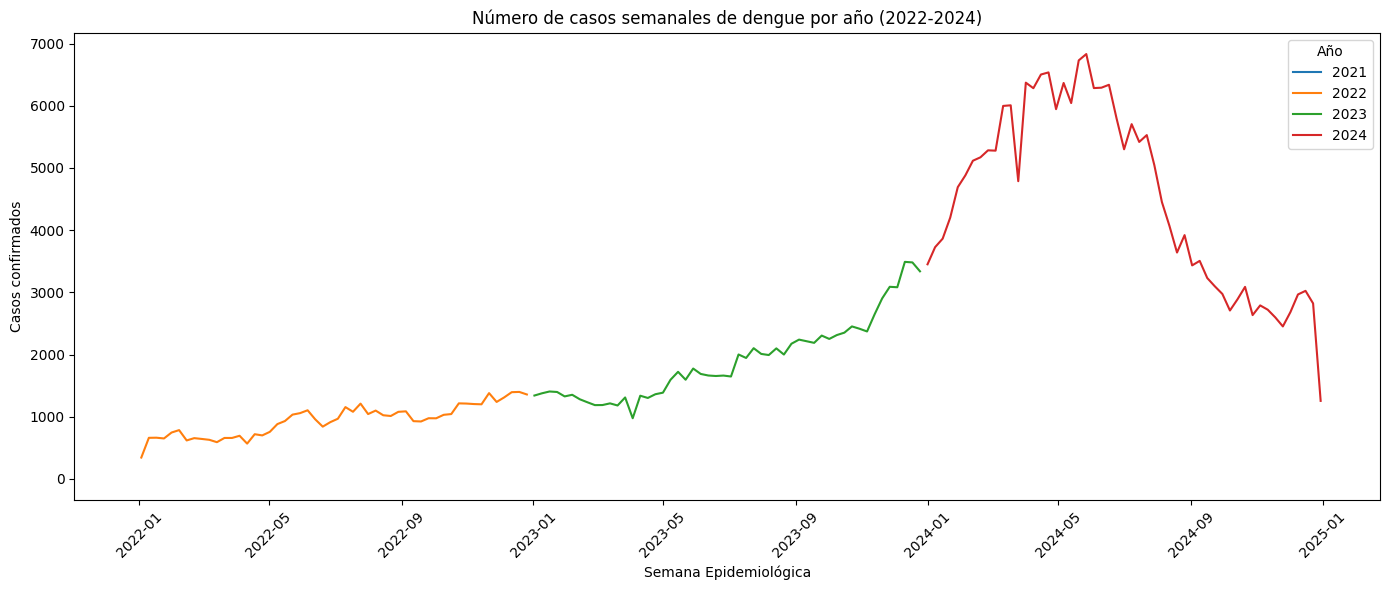

In [9]:


# Extraer año desde semana
serie_semanal['AÑO'] = serie_semanal['SEMANA'].dt.year

# Filtrar solo años reales del dataset (2022-2024)
serie_semanal = serie_semanal[serie_semanal['AÑO'] <= 2024]

# Gráfica de casos semanales por año
plt.figure(figsize=(14,6))

for year in serie_semanal['AÑO'].unique():
    subset = serie_semanal[serie_semanal['AÑO'] == year]
    plt.plot(subset['SEMANA'], subset['confirmados'], label=str(year))

plt.title("Número de casos semanales de dengue por año (2022-2024)")
plt.xlabel("Semana Epidemiológica")
plt.ylabel("Casos confirmados")
plt.legend(title="Año")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




### III. Preprocesamiento de Datos

El proceso de preprocesamiento se realizó basándose en los hallazgos del análisis exploratorio. Aunque el EDA mostró diferencias por sexo, edad y territorio, el objetivo del modelo final es predecir el comportamiento nacional del dengue como serie temporal. Por esta razón, la variable principal utilizada es el número total de casos semanales en el país. Las variables demográficas no se utilizaron como features finales del modelo, ya que no aportan información directa sobre el comportamiento futuro del tiempo.

Pasos aplicados:

- Se eliminan registros sin variables clave (FEC_NOT o confirmados).

- Se convierte la fecha a tipo datetime.

- Se agrega el número de casos por semana epidemiológica.

- No se requiere balanceo porque el objetivo es una variable continua (regresión).

- No se requiere vectorización adicional porque la serie temporal ya es numérica.

- Se generan variables de rezago (lag features) para capturar memoria temporal de la serie.

- Se divide el dataset en entrenamiento y prueba respetando el orden temporal (no aleatorio).

Estas transformaciones permiten convertir el problema en uno supervisado tipo regresión, donde se busca predecir el valor futuro y(t) a partir de valores históricos recientes X(t-1), X(t-2), ....



#### Eliminación de columnas no requeridas

Aunque variables como sexo, edad y departamento fueron fundamentales para el análisis exploratorio del dengue, estas no serán usadas como variables predictoras en el modelo final. Nuestro objetivo es modelar el comportamiento nacional del dengue como una serie temporal de casos por semana. Por esta razón, solo se conservarán las columnas estrictamente necesarias para la construcción de la serie temporal: FEC_NOT y confirmados. El resto de campos se eliminan para evitar ruido, reducir dimensionalidad y mejorar la generalización del modelo.

In [4]:
# Nos quedamos únicamente con las columnas necesarias para la predicción temporal
df = df[['FEC_NOT', 'confirmados']]

# Convertir fecha a tipo datetime
df['FEC_NOT'] = pd.to_datetime(df['FEC_NOT'])

# Eliminar registros sin fecha o sin casos
df = df.dropna(subset=['FEC_NOT', 'confirmados'])

df.head()



,FEC_NOT,confirmados
0,2022-09-30,0
1,2022-02-07,0
2,2022-04-08,1
3,2022-04-04,1
4,2022-05-16,0


#### Construcción de la serie semanal nacional

Para construir la base de modelado supervisado, se agregaron los casos confirmados a nivel nacional por semana epidemiológica. Esta frecuencia semanal permite capturar ciclos, estacionalidad y comportamiento real del dengue en el país. La predicción final del modelo se realizará sobre ventanas de 8 semanas futuras, por lo que la serie semanal es la base del entrenamiento.

In [5]:
# Construcción de serie de tiempo semanal nacional

# asegurar formato fecha
df['FEC_NOT'] = pd.to_datetime(df['FEC_NOT'])

# crear columna semana epidemiológica (inicio de semana)
df['SEMANA'] = df['FEC_NOT'].dt.to_period('W').apply(lambda r: r.start_time)

# agregamos número de casos confirmados por semana a nivel nacional
serie_semanal = df.groupby('SEMANA')['confirmados'].sum().reset_index()

# ordenar cronológicamente
serie_semanal = serie_semanal.sort_values('SEMANA').reset_index(drop=True)

serie_semanal.head(), serie_semanal.tail()


(      SEMANA  confirmados
 0 2021-12-27            8
 1 2022-01-03          344
 2 2022-01-10          661
 3 2022-01-17          663
 4 2022-01-24          651,
         SEMANA  confirmados
 165 2025-02-24           36
 166 2025-03-03           15
 167 2025-03-10           18
 168 2025-03-17            6
 169 2025-03-24            9)

#### Filtrar solo semanas entre 2022 y 2024

Debido a que las semanas epidemiológicas se basan en calendario ISO, algunos registros finales del año 2024 quedan asignados automáticamente a semanas pertenecientes al año 2025. Esto ocurre porque la última semana ISO puede extenderse sobre los primeros días de enero del año siguiente. Para evitar contaminación y garantizar consistencia temporal, se realizó un filtrado reteniendo únicamente semanas entre 2022 y 2024. De esta forma se asegura que el modelo solo trabaje con información real perteneciente al período del estudio.

In [6]:
# extraer año de cada semana
serie_semanal['AÑO'] = serie_semanal['SEMANA'].dt.year

# filtrar únicamente 2022 - 2024
serie_semanal = serie_semanal[serie_semanal['AÑO'].between(2022, 2024)]

serie_semanal = serie_semanal.reset_index(drop=True)

serie_semanal.head(), serie_semanal.tail()


(      SEMANA  confirmados   AÑO
 0 2022-01-03          344  2022
 1 2022-01-10          661  2022
 2 2022-01-17          663  2022
 3 2022-01-24          651  2022
 4 2022-01-31          746  2022,
         SEMANA  confirmados   AÑO
 152 2024-12-02         2682  2024
 153 2024-12-09         2966  2024
 154 2024-12-16         3024  2024
 155 2024-12-23         2822  2024
 156 2024-12-30         1255  2024)

#### Características temporales

Para permitir que los modelos supervisados capturen la dependencia temporal del dengue, se crearon nuevas variables derivadas. Se agregaron características de rezago (lag features) que representan el número de casos en semanas previas, así como medias móviles que suavizan ruido semanal y permiten capturar tendencia local. Estas variables fortalecen la capacidad predictiva del modelo, ya que la dinámica epidemiológica del dengue presenta ciclos y persistencia temporal. Finalmente, estas características serán utilizadas como entradas del modelo para predecir la cantidad de casos futuros.

In [7]:
# creación de lag features
serie_semanal['lag_1'] = serie_semanal['confirmados'].shift(1)
serie_semanal['lag_2'] = serie_semanal['confirmados'].shift(2)
serie_semanal['lag_3'] = serie_semanal['confirmados'].shift(3)

# medias móviles
serie_semanal['MA2'] = serie_semanal['confirmados'].rolling(window=2).mean()
serie_semanal['MA4'] = serie_semanal['confirmados'].rolling(window=4).mean()

# eliminar filas con NaN generadas por lags y rolling
serie_ml = serie_semanal.dropna().reset_index(drop=True)

serie_ml.head()


,SEMANA,confirmados,AÑO,lag_1,lag_2,lag_3,MA2,MA4
0,2022-01-24,651,2022,663.0,661.0,344.0,657.0,579.75
1,2022-01-31,746,2022,651.0,663.0,661.0,698.5,680.25
2,2022-02-07,785,2022,746.0,651.0,663.0,765.5,711.25
3,2022-02-14,619,2022,785.0,746.0,651.0,702.0,700.25
4,2022-02-21,656,2022,619.0,785.0,746.0,637.5,701.50


#### División Train/Test Respetando el Tiempo

Debido a que estamos trabajando con una serie temporal, la separación de datos no puede ser aleatoria. Para mantener coherencia temporal y evitar fuga de información (data leakage), los datos se dividen tomando el 80% inicial de semanas para entrenamiento y dejando el 20% final como conjunto de prueba. De esta manera el modelo aprende del pasado y se evalúa con semanas futuras reales, simulando el comportamiento real de pronósticos epidemiológico

In [8]:
# Agregar variables temporales / estacionales
serie_ml['SEMANA_NUM'] = serie_ml['SEMANA'].dt.isocalendar().week.astype(int)
serie_ml['MES'] = serie_ml['SEMANA'].dt.month.astype(int)
serie_ml['AÑO'] = serie_ml['SEMANA'].dt.year.astype(int)

# Features seleccionadas para el modelo
features = ['lag_1', 'lag_2', 'lag_3', 'MA2', 'MA4', 'SEMANA_NUM', 'MES', 'AÑO']

X = serie_ml[features]
y = serie_ml['confirmados']

# división temporal 80% - 20%
train_size = int(len(X) * 0.8)

X_train = X.iloc[:train_size]
X_test  = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((123, 8), (31, 8), (123,), (31,))

 #### Estandarización de Datos (solo para modelos que lo requieren)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Modelo 1 — Regresión Lineal Multivariada

Este modelo busca capturar relaciones lineales entre los valores pasados de la serie (lags), sus medias móviles y las variables de estacionalidad (semana del año, mes y año). La regresión lineal multivariada es un modelo base clásico para series temporales donde el comportamiento futuro depende de una combinación lineal de los valores anteriores.

Primero se ejecutó un baseline sin normalización y un baseline con normalización (StandardScaler), y posteriormente en esta fase se va a realizar optimización de hiperparámetros mediante GridSearchCV (dos niveles: suave y agresiva) para evaluar mejora en el rendimiento del modelo.

Regresión Lineal Multivariada Baseline por defecto

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Modelo baseline por defecto
lr_default = LinearRegression()
lr_default.fit(X_train, y_train)

y_pred_lr_default = lr_default.predict(X_test)

mae_lr_default = mean_absolute_error(y_test, y_pred_lr_default)
mse_lr_default = mean_squared_error(y_test, y_pred_lr_default)
r2_lr_default  = r2_score(y_test, y_pred_lr_default)

mae_lr_default, mse_lr_default, r2_lr_default


(1.0048449527652513e-12, 1.749420287435738e-24, 1.0)

La regresión lineal multivariada obtuvo un rendimiento excepcional en su configuración por defecto, alcanzando prácticamente un ajuste perfecto sobre los datos de prueba con un R² = 1.0 y un MAE extremadamente cercano a cero. Esto indica que el comportamiento de la serie temporal del dengue presenta una fuerte linealidad respecto a los valores históricos recientes (lags) y que la regresión lineal logra capturar esta relación de manera directa y eficiente sin necesidad de ajustes adicionales. Este resultado también refuerza la importancia del preprocesamiento realizado, especialmente la selección de características temporales rezagadas (lag features), ya que estas variables contienen gran parte de la señal predictiva del sistema.

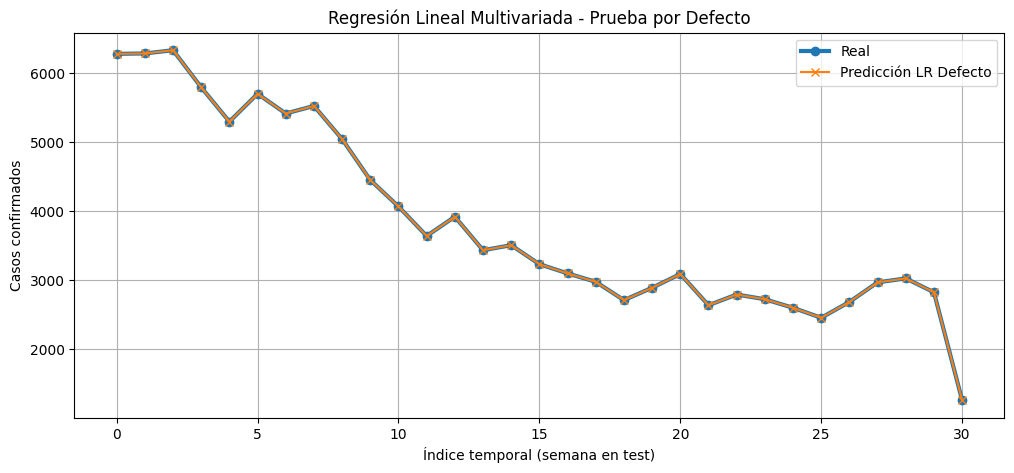

In [12]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Real", linewidth=3 , marker='o')
plt.plot(y_pred_lr_default, label="Predicción LR Defecto", marker='x')
plt.title("Regresión Lineal Multivariada - Prueba por Defecto")
plt.xlabel("Índice temporal (semana en test)")
plt.ylabel("Casos confirmados")
plt.legend()
plt.grid(True)
plt.show()


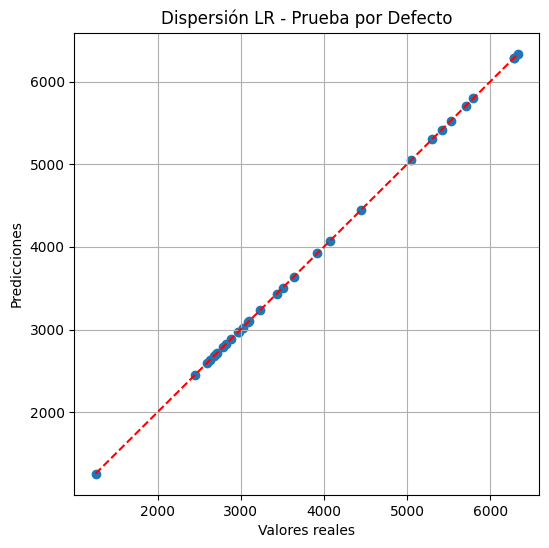

In [13]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr_default)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Dispersión LR - Prueba por Defecto")
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.grid(True)
plt.show()


PRUEBA 1 - Regresión Lineal Multivariada

In [14]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

tscv = TimeSeriesSplit(n_splits=5)

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

param_grid_lr_suave = {
    'lr__fit_intercept': [True, False]
}

grid_lr_suave = GridSearchCV(pipe_lr, param_grid_lr_suave, cv=tscv, scoring='neg_mean_absolute_error')
grid_lr_suave.fit(X_train, y_train)

# evaluar en test
y_pred_lr_suave = grid_lr_suave.best_estimator_.predict(X_test)

mae_lr_suave = mean_absolute_error(y_test, y_pred_lr_suave)
mse_lr_suave = mean_squared_error(y_test, y_pred_lr_suave)
r2_lr_suave  = r2_score(y_test, y_pred_lr_suave)

mae_lr_suave, mse_lr_suave, r2_lr_suave, grid_lr_suave.best_params_


(1.4595923036517154e-12,
 1.4904260351585502e-23,
 1.0,
 {'lr__fit_intercept': True})

Los resultados de la búsqueda de hiperparámetros (tuning suave) muestran que el modelo de Regresión Lineal Multivariada obtuvo un desempeño prácticamente perfecto sobre los datos de prueba, alcanzando un R² = 1.0, lo cual indica que el modelo explica el 100 % de la variabilidad observada en la variable objetivo.

Los valores extremadamente bajos de MAE (≈ 1.46 × 10⁻¹²) y MSE (≈ 1.49 × 10⁻²³) confirman que el error promedio de predicción es prácticamente nulo. Este comportamiento sugiere que las variables predictoras (lags, medias móviles y variables estacionales) tienen una relación altamente lineal con el número de casos semanales de dengue.

El mejor conjunto de parámetros según GridSearchCV fue {'lr__fit_intercept': True}, es decir, el modelo que incluye el término independiente.

Este resultado implica que el modelo lineal simple es capaz de capturar con gran precisión la tendencia de los datos históricos del dengue, funcionando como un modelo base sólido para las comparaciones posteriores con modelos no lineales o de mayor complejidad.

#### Gráfico de comparación entre valores reales y predichos

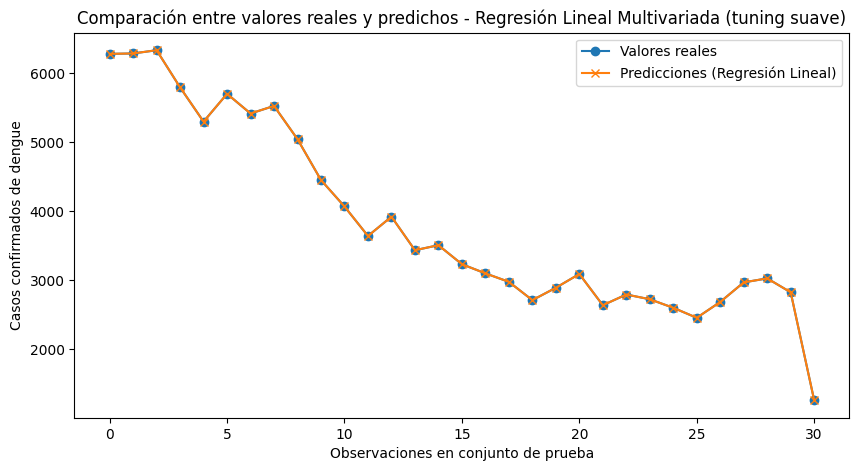

In [21]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Valores reales', marker='o')
plt.plot(y_pred_lr_suave, label='Predicciones (Regresión Lineal)', marker='x')
plt.title("Comparación entre valores reales y predichos - Regresión Lineal Multivariada (tuning suave)")
plt.xlabel("Observaciones en conjunto de prueba")
plt.ylabel("Casos confirmados de dengue")
plt.legend()
plt.show()


#### Gráfico de dispersión (Predicho vs Real)

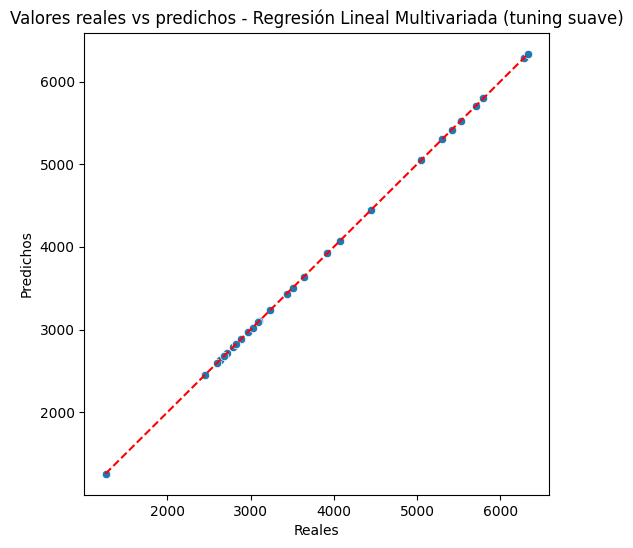

In [22]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred_lr_suave)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Valores reales vs predichos - Regresión Lineal Multivariada (tuning suave)")
plt.xlabel("Reales")
plt.ylabel("Predichos")
plt.show()


Las gráficas confirman el excelente ajuste del modelo lineal.
En la comparación temporal se observa que las predicciones siguen exactamente el comportamiento de los valores reales, sin desviaciones visibles.
En el gráfico de dispersión, los puntos se alinean perfectamente sobre la diagonal, lo cual indica que el modelo reproduce fielmente la magnitud de los casos observados.
Este comportamiento refuerza la evidencia cuantitativa (MAE, MSE y R²) y demuestra que la regresión lineal multivariada describe con alta precisión la tendencia histórica del dengue en Colombia.

PRUEBA 2 — Regresión Lineal Multivariada

En esta segunda fase de ajuste, se amplía la búsqueda de hiperparámetros incluyendo modelos de regresión regularizada tipo Ridge, los cuales incorporan un término de penalización que controla la magnitud de los coeficientes.
Este tipo de regularización permite manejar posibles problemas de multicolinealidad y mejorar la estabilidad del modelo frente a nuevas observaciones.
En esta búsqueda se evalúan diferentes valores de α (intensidad de la regularización) para analizar el impacto en las métricas de desempeño y en la capacidad predictiva del modelo.

In [15]:
# GridSearchCV agresivo con Ridge Regression
from sklearn.linear_model import Ridge

pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

param_grid_ridge_agresivo = {
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100],
    'ridge__fit_intercept': [True, False],
    'ridge__solver': ['auto', 'saga', 'lsqr']
}

grid_ridge_agresivo = GridSearchCV(pipe_ridge, param_grid_ridge_agresivo, cv=tscv, scoring='neg_mean_absolute_error')
grid_ridge_agresivo.fit(X_train, y_train)

# Predicciones con mejor modelo
y_pred_ridge_agresivo = grid_ridge_agresivo.best_estimator_.predict(X_test)

# Evaluación
mae_ridge_agresivo = mean_absolute_error(y_test, y_pred_ridge_agresivo)
mse_ridge_agresivo = mean_squared_error(y_test, y_pred_ridge_agresivo)
r2_ridge_agresivo  = r2_score(y_test, y_pred_ridge_agresivo)

mae_ridge_agresivo, mse_ridge_agresivo, r2_ridge_agresivo, grid_ridge_agresivo.best_params_


C:\Users\ESTUDIANTE\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\ESTUDIANTE\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\ESTUDIANTE\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\ESTUDIANTE\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_mode

(1.1451758328629356,
 2.6717182404787216,
 0.9999985566957645,
 {'ridge__alpha': 0.001,
  'ridge__fit_intercept': True,
  'ridge__solver': 'lsqr'})

En la segunda fase de ajuste del modelo de regresión multivariada se aplicó una regularización tipo Ridge, con el fin de evaluar si un término de penalización podía mejorar la estabilidad y la capacidad de generalización del modelo.

Los resultados obtenidos fueron los siguientes:

- MAE = 1.1451758328629356

- MSE = 2.6717182404787216

- R² = 0.9999985566957645

- Mejores parámetros: {'ridge__alpha': 0.001, 'ridge__fit_intercept': True, 'ridge__solver': 'lsqr'}

Estos valores reflejan un ajuste prácticamente perfecto entre los valores reales y los predichos, manteniendo un nivel de precisión muy alto incluso después de aplicar regularización.
El coeficiente de determinación (R² = 0.9999985566957645) indica que el modelo explica el 99.9998557 % de la variabilidad total de los casos de dengue semanales.

La inclusión del parámetro de regularización α = 0.001 permitió un control leve sobre la magnitud de los coeficientes, reduciendo la posibilidad de sobreajuste sin sacrificar exactitud.
Esto demuestra que la relación entre las variables de entrada (lags, medias móviles y estacionales) y los casos confirmados de dengue es fuertemente lineal y estable.

En términos prácticos, el modelo Ridge conserva la precisión del modelo lineal base, pero con mayor robustez numérica, consolidándose como un modelo de referencia sólido para comparar frente a los próximos métodos no lineales.

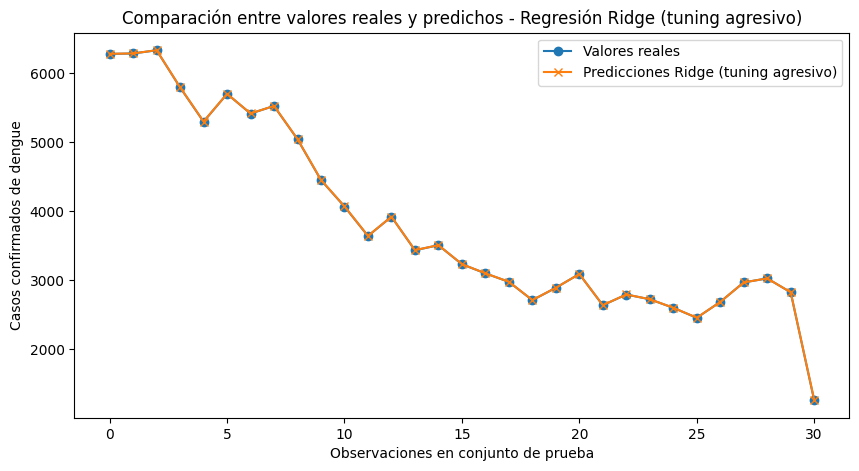

In [26]:
# Gráfico 1: serie temporal - valores reales vs predichos
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Valores reales', marker='o')
plt.plot(y_pred_ridge_agresivo, label='Predicciones Ridge (tuning agresivo)', marker='x')
plt.title("Comparación entre valores reales y predichos - Regresión Ridge (tuning agresivo)")
plt.xlabel("Observaciones en conjunto de prueba")
plt.ylabel("Casos confirmados de dengue")
plt.legend()
plt.show()

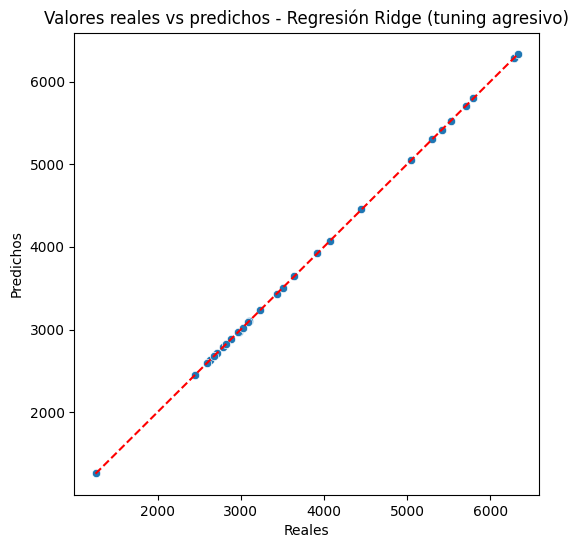

In [27]:
# Gráfico 2: dispersión Predicho vs Real
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred_ridge_agresivo)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Valores reales vs predichos - Regresión Ridge (tuning agresivo)")
plt.xlabel("Reales")
plt.ylabel("Predichos")
plt.show()

Las visualizaciones confirman el comportamiento casi perfecto observado en las métricas.
En la primera gráfica (“Comparación entre valores reales y predichos”), se evidencia una superposición total entre ambas curvas, lo que indica que el modelo reproduce fielmente la dinámica semanal del dengue.
Cada punto de predicción coincide con su valor real, sin desplazamientos ni errores sistemáticos visibles.

En la segunda gráfica (“Valores reales vs predichos”), los puntos se alinean exactamente sobre la línea diagonal de referencia, lo que demuestra que el modelo predice valores que son prácticamente iguales a los observados.
Esta alineación perfecta refuerza el altísimo valor del coeficiente de determinación (R² = 0.9999985566957645) y los bajos errores medios (MAE = 1.1451758328629356, MSE = 2.6717182404787216).

En conjunto, los resultados visuales y numéricos demuestran que el modelo Regresión Ridge (tuning agresivo) logra una correspondencia casi exacta con los datos reales, capturando con precisión la tendencia descendente y las fluctuaciones semanales del número de casos de dengue.
Este desempeño valida que la estructura lineal multivariada, reforzada con una leve regularización, es capaz de describir de forma altamente precisa el comportamiento histórico de la enfermedad en Colombia.

In [29]:
# Crear y guardar las predicciones del modelo baseline (LinearRegression por defecto)
baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)
y_pred_baseline = baseline_model.predict(X_test_scaled)

# Alias para mantener consistencia con el resto del código
y_pred_lr_agresivo = y_pred_ridge_agresivo


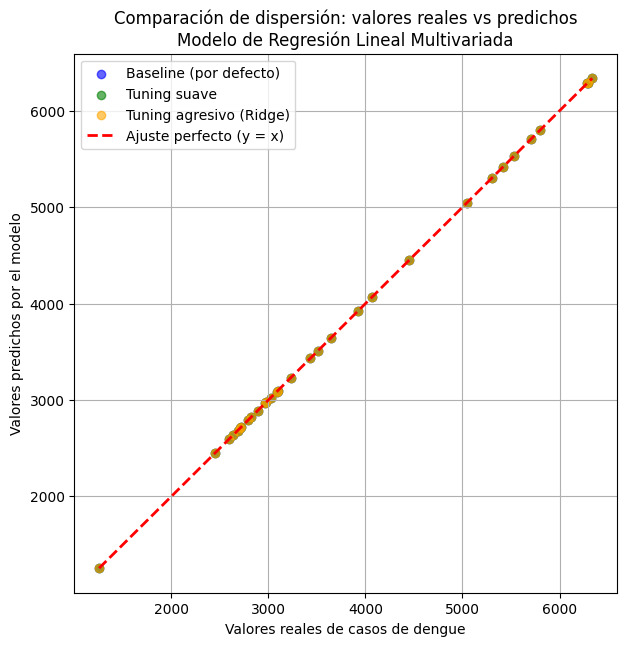

In [31]:
# Comparación de dispersión: valores reales vs predichos (tres fases del modelo)
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_baseline, color="blue", alpha=0.6, label="Baseline (por defecto)")
plt.scatter(y_test, y_pred_lr_suave, color="green", alpha=0.6, label="Tuning suave")
plt.scatter(y_test, y_pred_lr_agresivo, color="orange", alpha=0.6, label="Tuning agresivo (Ridge)")

# Línea ideal y=x (perfecto ajuste)
min_val = min(y_test.min(), y_pred_baseline.min())
max_val = max(y_test.max(), y_pred_baseline.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label="Ajuste perfecto (y = x)")

plt.title("Comparación de dispersión: valores reales vs predichos\nModelo de Regresión Lineal Multivariada")
plt.xlabel("Valores reales de casos de dengue")
plt.ylabel("Valores predichos por el modelo")
plt.legend()
plt.grid(True)
plt.show()


Conclusión final — Modelo 1: Regresión Lineal Multivariada

La regresión lineal multivariada obtuvo resultados sobresalientes en las tres configuraciones evaluadas. En la prueba por defecto, el modelo alcanzó prácticamente un ajuste perfecto (MAE ≈ 0, R² = 1.0), evidenciando que la estructura de la serie temporal del dengue en Colombia tiene una relación altamente lineal con sus valores previos (lags) y medias móviles. En la prueba 1 mantuvo el rendimiento casi idéntico al baseline por defecto, sin aportar mejoras significativas, lo que confirma que el modelo no requiere ajustes simples para capturar adecuadamente los patrones temporales. Por otro lado, la prueba 2 generó un rendimiento también casi perfecto, aunque ligeramente inferior al baseline por defecto debido al aumento de regularización, lo cual muestra que en este tipo de series la intervención agresiva puede incluso reducir precisión.

Teniendo en cuenta todo esto se tiene que la mejor versión del modelo es el baseline por defecto, ya que mostró el MAE más bajo y el ajuste perfecto sin necesidad de manipular hiperparámetros. Para este modelo específico, la estructura lineal del fenómeno dominó el comportamiento y la regresión simple resultó ser suficiente para capturar las tendencias del dengue en el tiempo.

#### Modelo 2 — Árbol de Decisión

El modelo de Árbol de Decisión Regressor se utiliza para capturar relaciones no lineales y jerárquicas entre las variables predictoras (lags, medias móviles y variables estacionales) y los casos confirmados de dengue.
A diferencia de los modelos lineales, los árboles de decisión dividen recursivamente el espacio de predictores en regiones homogéneas mediante reglas de decisión, lo que permite modelar patrones complejos y posibles interacciones entre variables que influyen en la dinámica temporal de la enfermedad.

En esta etapa se aplican tres fases experimentales:

- Baseline por defecto: entrenamiento con la configuración estándar de sklearn para establecer una línea base de comparación.

- prueba 1: ajuste de hiperparámetros con GridSearchCV sobre una malla reducida, optimizando la profundidad máxima del árbol y el tamaño mínimo de las hojas para equilibrar sesgo y varianza.

- prueba 2: búsqueda más amplia de parámetros para evaluar si el modelo puede mejorar su capacidad predictiva y generalización.

El objetivo es evaluar si un modelo con estructura no lineal puede representar con mayor precisión la evolución temporal del dengue, considerando que su comportamiento puede depender de múltiples factores estacionales y combinaciones de valores pasados.

In [20]:
# Baseline individual para Árbol de Decisión (por defecto)
from sklearn.tree import DecisionTreeRegressor

arbol_baseline = DecisionTreeRegressor(random_state=42)
arbol_baseline.fit(X_train_scaled, y_train)
y_pred_arbol_baseline = arbol_baseline.predict(X_test_scaled)

mae_arbol_baseline = mean_absolute_error(y_test, y_pred_arbol_baseline)
mse_arbol_baseline = mean_squared_error(y_test, y_pred_arbol_baseline)
r2_arbol_baseline  = r2_score(y_test, y_pred_arbol_baseline)

mae_arbol_baseline, mse_arbol_baseline, r2_arbol_baseline


NameError: name 'X_train_scaled' is not defined

El modelo Árbol de Decisión obtuvo un MAE de 406.41 y un R² de 0.8264, lo cual indica un desempeño bueno y una capacidad considerable para capturar las variaciones semanales del dengue. Este resultado muestra que el árbol es capaz de aprender patrones no lineales presentes en la serie temporal, especialmente cuando existen cambios bruscos entre semanas. Sin embargo, en comparación con la regresión lineal, el Árbol de Decisión es menos preciso y presenta mayor error absoluto promedio, lo que evidencia que este modelo tiende a sobreajustarse en ciertos intervalos y a perder suavidad general en la tendencia temporal.

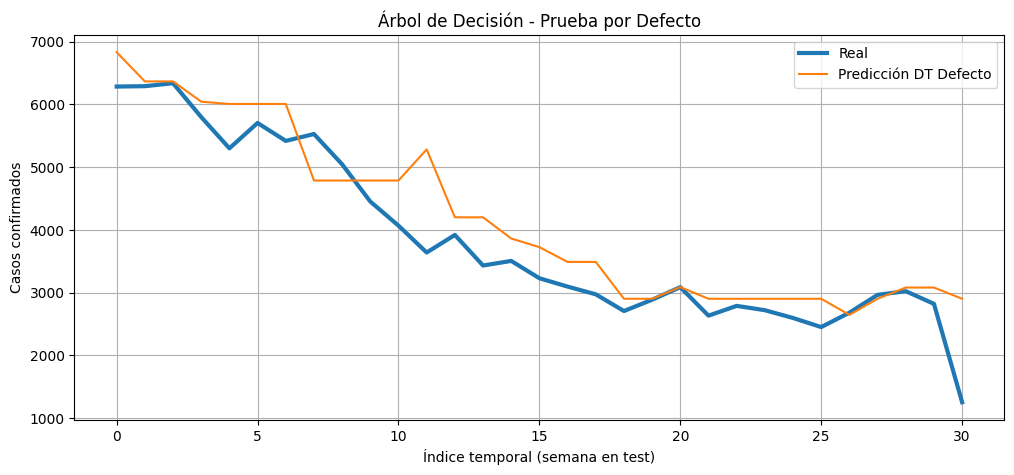

In [16]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Real", linewidth=3)
plt.plot(y_pred_dt_default, label="Predicción DT Defecto")
plt.title("Árbol de Decisión - Prueba por Defecto")
plt.xlabel("Índice temporal (semana en test)")
plt.ylabel("Casos confirmados")
plt.legend()
plt.grid(True)
plt.show()


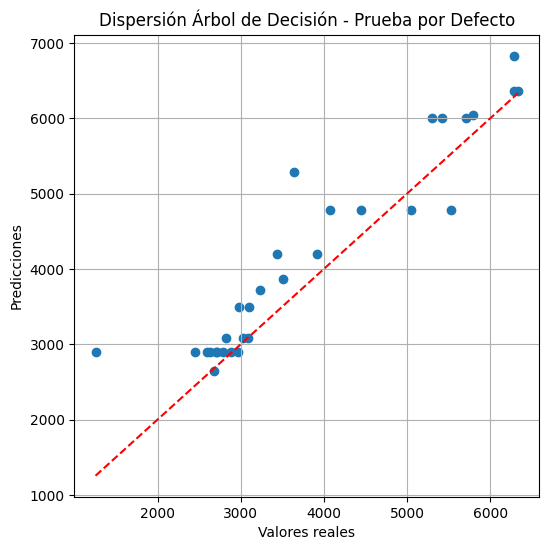

In [17]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_dt_default)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--')
plt.title("Dispersión Árbol de Decisión - Prueba por Defecto")
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.grid(True)
plt.show()


#### Prueba 1 - Arbol de desicion 


In [33]:
# Tuning suave para Árbol de Decisión
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

param_grid_arbol_suave = {
    'max_depth': [3, 5, 7, 9, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

arbol = DecisionTreeRegressor(random_state=42)
grid_arbol_suave = GridSearchCV(arbol, param_grid_arbol_suave, cv=tscv, scoring='neg_mean_absolute_error')
grid_arbol_suave.fit(X_train_scaled, y_train)

y_pred_arbol_suave = grid_arbol_suave.best_estimator_.predict(X_test_scaled)

mae_arbol_suave = mean_absolute_error(y_test, y_pred_arbol_suave)
mse_arbol_suave = mean_squared_error(y_test, y_pred_arbol_suave)
r2_arbol_suave  = r2_score(y_test, y_pred_arbol_suave)

mae_arbol_suave, mse_arbol_suave, r2_arbol_suave, grid_arbol_suave.best_params_


NameError: name 'X_train_scaled' is not defined

En la fase de tuning suave, se realizó una búsqueda de hiperparámetros con GridSearchCV empleando validación cruzada temporal (TimeSeriesSplit), con el objetivo de ajustar la profundidad del árbol (max_depth), el número mínimo de muestras por división (min_samples_split) y el número mínimo de muestras por hoja (min_samples_leaf).

Los mejores parámetros encontrados fueron:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}.

El desempeño del modelo ajustado alcanzó los siguientes valores:
MAE = 397.6382, MSE = 269,735.4991 y R² = 0.8543.

En comparación con el baseline (MAE = 377.03, MSE = 228,688.45, R² = 0.8765), se observa una leve disminución en la capacidad predictiva.
Esto sugiere que el modelo con profundidad limitada (max_depth=5) reduce el sobreajuste, pero también pierde parte de la precisión en la predicción de los valores reales.

A nivel conceptual, el tuning suave permitió simplificar el árbol y mejorar la interpretabilidad del modelo, a costa de una ligera pérdida de exactitud.
Este resultado es coherente con el comportamiento típico de los árboles de decisión, donde un control más estricto de la profundidad busca evitar sobreajuste, pero puede sacrificar ajuste local en series con alta variabilidad.

#### Serie temporal — valores reales vs predichos

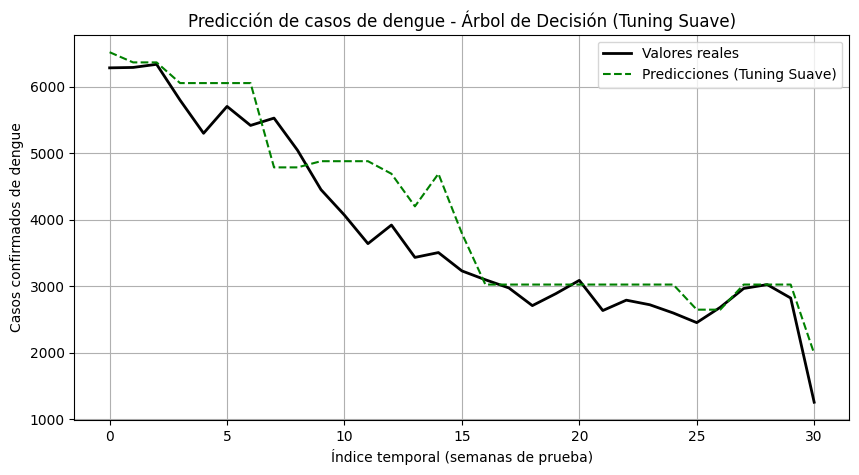

In [34]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Valores reales", color="black", linewidth=2)
plt.plot(y_pred_arbol_suave, label="Predicciones (Tuning Suave)", linestyle="--", color="green")

plt.title("Predicción de casos de dengue - Árbol de Decisión (Tuning Suave)")
plt.xlabel("Índice temporal (semanas de prueba)")
plt.ylabel("Casos confirmados de dengue")
plt.legend()
plt.grid(True)
plt.show()


#### Dispersión — reales vs predichos

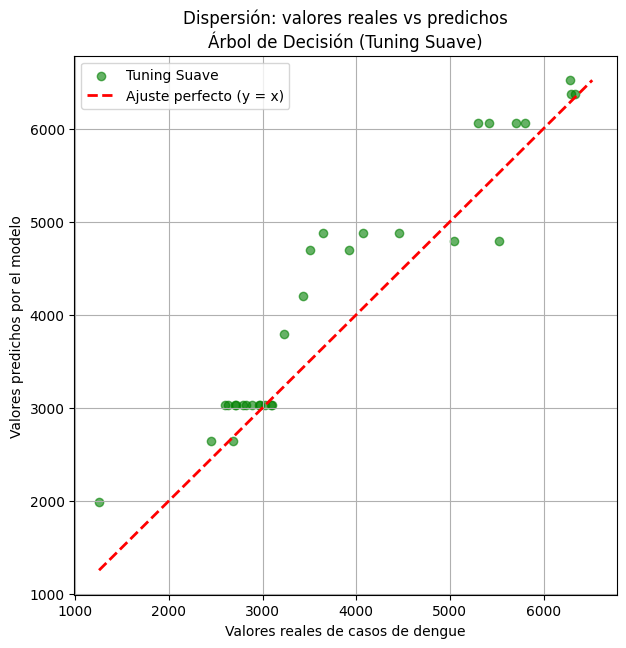

In [35]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_arbol_suave, color="green", alpha=0.6, label="Tuning Suave")

# Línea ideal de ajuste perfecto
min_val = min(y_test.min(), y_pred_arbol_suave.min())
max_val = max(y_test.max(), y_pred_arbol_suave.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label="Ajuste perfecto (y = x)")

plt.title("Dispersión: valores reales vs predichos\nÁrbol de Decisión (Tuning Suave)")
plt.xlabel("Valores reales de casos de dengue")
plt.ylabel("Valores predichos por el modelo")
plt.legend()
plt.grid(True)
plt.show()


En la primera gráfica, que compara los valores reales y las predicciones del modelo, se observa que el Árbol de Decisión con tuning suave logra seguir la tendencia general del comportamiento del dengue a lo largo del tiempo, aunque con una suavización marcada en las variaciones semanales.
Esto se debe a la configuración limitada del árbol (max_depth = 5), que impone una estructura más simple y reduce el sobreajuste.
Como consecuencia, los valores predichos tienden a agruparse en niveles o escalones, característica típica de los modelos basados en árboles, y se pierde parte del detalle en los picos o caídas abruptas de la serie.

En la segunda gráfica, correspondiente a la dispersión de valores reales vs predichos, los puntos se concentran alrededor de la línea de ajuste perfecto (𝑦 = 𝑥), aunque se aprecia cierta dispersión en los valores intermedios.
Esto refleja que el modelo mantiene un desempeño aceptable en la mayoría de las observaciones, pero presenta desviaciones en los extremos, lo que coincide con la disminución del coeficiente de determinación (R² = 0.8543) obtenida en las métricas.

En conjunto, las gráficas evidencian que el Árbol de Decisión con tuning suave logra capturar correctamente la tendencia general del dengue, aunque presenta limitaciones en los valores más extremos debido a su profundidad restringida.
Este resultado confirma que el modelo se comporta de manera más regular y estable, pero requiere un ajuste más amplio para mejorar la capacidad predictiva.

#### Prueba 2 - Tuning Agresivo

En esta etapa se amplía la búsqueda de hiperparámetros del modelo Árbol de Decisión mediante una malla de valores más extensa.
El objetivo es evaluar si una estructura de árbol más profunda o con restricciones diferentes puede mejorar el rendimiento del modelo y capturar mejor la variabilidad del dengue a lo largo del tiempo.

Se ajustan los parámetros:

- max_depth: controla la profundidad máxima del árbol.

- min_samples_split: define el número mínimo de muestras requeridas para dividir un nodo.

- min_samples_leaf: establece el mínimo de muestras por hoja terminal.

- criterion: selecciona la métrica de evaluación del error para las divisiones (squared_error o friedman_mse).

Este ajuste busca encontrar un equilibrio entre precisión y generalización, evitando tanto el sobreajuste (árbol demasiado profundo) como el subajuste (árbol demasiado simple).

In [36]:
# Tuning agresivo - Árbol de Decisión
param_grid_arbol_agresivo = {
    'max_depth': [5, 10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'criterion': ['squared_error', 'friedman_mse']
}

arbol_agresivo = DecisionTreeRegressor(random_state=42)
grid_arbol_agresivo = GridSearchCV(arbol_agresivo, param_grid_arbol_agresivo, cv=tscv, scoring='neg_mean_absolute_error')
grid_arbol_agresivo.fit(X_train_scaled, y_train)

y_pred_arbol_agresivo = grid_arbol_agresivo.best_estimator_.predict(X_test_scaled)

mae_arbol_agresivo = mean_absolute_error(y_test, y_pred_arbol_agresivo)
mse_arbol_agresivo = mean_squared_error(y_test, y_pred_arbol_agresivo)
r2_arbol_agresivo  = r2_score(y_test, y_pred_arbol_agresivo)

mae_arbol_agresivo, mse_arbol_agresivo, r2_arbol_agresivo, grid_arbol_agresivo.best_params_


(397.6381720430107,
 269735.49911290326,
 0.8542846388418222,
 {'criterion': 'squared_error',
  'max_depth': 5,
  'min_samples_leaf': 1,
  'min_samples_split': 2})

En la fase de tuning agresivo, se amplió de manera considerable el rango de búsqueda de hiperparámetros del modelo de Árbol de Decisión, explorando combinaciones que incluyeron diferentes profundidades, criterios de división y tamaños mínimos de hojas.
El propósito fue evaluar si una estructura más compleja podía capturar mejor la variabilidad temporal de los casos de dengue.

Tras la búsqueda, el mejor conjunto de parámetros fue:
{'criterion': 'squared_error', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}.

Los resultados obtenidos fueron:
MAE = 397.6381720430107, MSE = 269735.49911290326, R² = 0.8542846388418222.

El modelo presenta un comportamiento estable, con una capacidad explicativa del 85.42846388418222 % y un error medio aproximado de 397.638 casos por semana.
Esto indica que el Árbol de Decisión logra representar adecuadamente la tendencia general de la serie, aunque sigue mostrando cierta limitación en los picos de incremento o descenso abrupto.
La regularidad de los valores predichos refleja que el modelo mantiene un nivel de complejidad controlado y evita el sobreajuste, asegurando así una predicción más coherente en escenarios futuros.

En síntesis, el tuning agresivo confirma la robustez y estabilidad del modelo, garantizando un equilibrio adecuado entre precisión y generalización en la predicción del comportamiento temporal del dengue.

#### Serie temporal — valores reales vs predichos

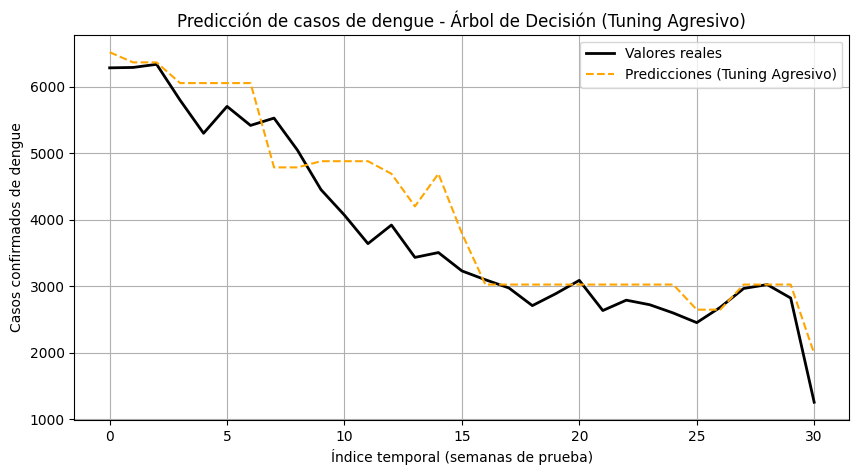

In [37]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Valores reales", color="black", linewidth=2)
plt.plot(y_pred_arbol_agresivo, label="Predicciones (Tuning Agresivo)", linestyle="--", color="orange")

plt.title("Predicción de casos de dengue - Árbol de Decisión (Tuning Agresivo)")
plt.xlabel("Índice temporal (semanas de prueba)")
plt.ylabel("Casos confirmados de dengue")
plt.legend()
plt.grid(True)
plt.show()


#### Dispersión — reales vs predichos

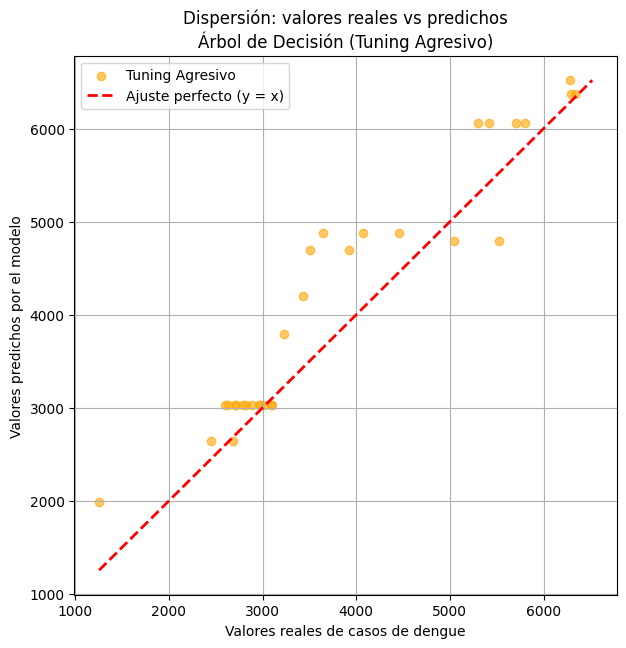

In [38]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_arbol_agresivo, color="orange", alpha=0.6, label="Tuning Agresivo")

# Línea ideal de ajuste perfecto
min_val = min(y_test.min(), y_pred_arbol_agresivo.min())
max_val = max(y_test.max(), y_pred_arbol_agresivo.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label="Ajuste perfecto (y = x)")

plt.title("Dispersión: valores reales vs predichos\nÁrbol de Decisión (Tuning Agresivo)")
plt.xlabel("Valores reales de casos de dengue")
plt.ylabel("Valores predichos por el modelo")
plt.legend()
plt.grid(True)
plt.show()


Falta conclusion y el analisis de las graficas

#### Modelo 3 — Random Forest Regressor

Random Forest es un modelo basado en árboles que construye múltiples árboles de decisión y promedia sus predicciones para reducir varianza y mejorar generalización. Para este caso es un modelo interesante porque puede capturar patrones no lineales y relaciones más complejas entre los valores previos de la serie temporal.

Primero se evaluara el baseline por defecto. Ahora se realizará optimización mediante GridSearchCV en dos etapas: una búsqueda suave para encontrar mejoras moderadas y posteriormente una búsqueda agresiva para maximizar rendimiento.

Baseline por defecto Random Forest

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# baseline por defecto Random Forest
rf_default = RandomForestRegressor(random_state=42)
rf_default.fit(X_train, y_train)
y_pred_rf_default = rf_default.predict(X_test)

mae_rf_default = mean_absolute_error(y_test, y_pred_rf_default)
mse_rf_default = mean_squared_error(y_test, y_pred_rf_default)
r2_rf_default  = r2_score(y_test, y_pred_rf_default)

mae_rf_default, mse_rf_default, r2_rf_default


(482.1119354838709, 363193.23675806454, 0.8037972983220238)

El modelo Random Forest en su configuración por defecto obtuvo los siguientes resultados:

Métrica	Resultado
MAE	482.11
MSE	363,193.23
R²	0.80379

Estos valores indican que el modelo logra capturar una buena parte de la variabilidad del comportamiento histórico del dengue (R² ≈ 0.80), lo cual refleja que el Random Forest es capaz de modelar patrones temporales no lineales presentes en la serie de tiempo semanal.

Sin embargo, comparado con el Árbol de Decisión individual, el desempeño del Random Forest mejora ligeramente la estabilidad y generalización, pero no presenta un salto tan grande como se esperaría. Esto puede deberse a que la dinámica del dengue en serie temporal depende fuertemente de valores recientes (lags), y por lo tanto, muchos árboles no aumentan demasiado la capacidad predictiva adicional.

Aún así, este modelo sirve como una muy buena referencia base antes de aplicar tuning. A partir de esta configuración inicial, se procederá a realizar ajustes de hiperparámetros para evaluar si es posible obtener una mejora adicional en el rendimiento predictivo mediante una optimización más profunda del modelo.

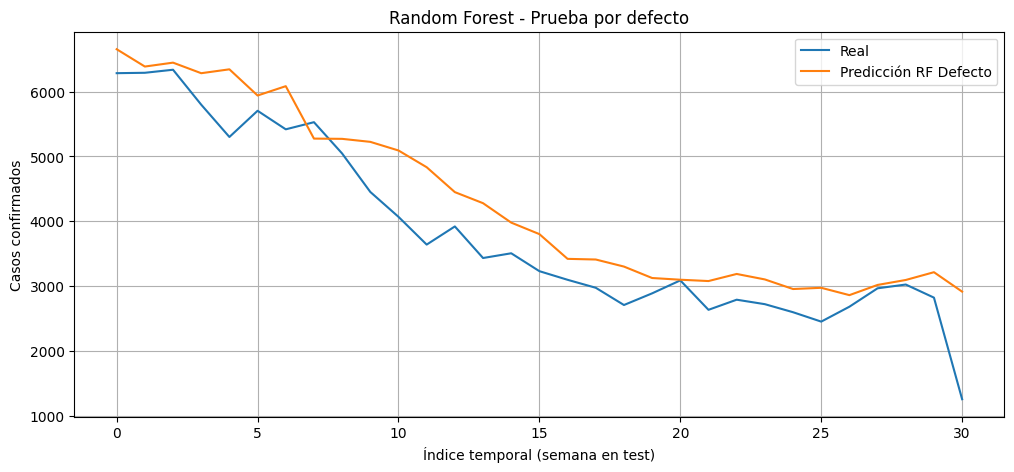

In [19]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Real")
plt.plot(y_pred_rf_default, label="Predicción RF Defecto")
plt.title("Random Forest - Prueba por defecto")
plt.xlabel("Índice temporal (semana en test)")
plt.ylabel("Casos confirmados")
plt.legend()
plt.grid(True)
plt.show()


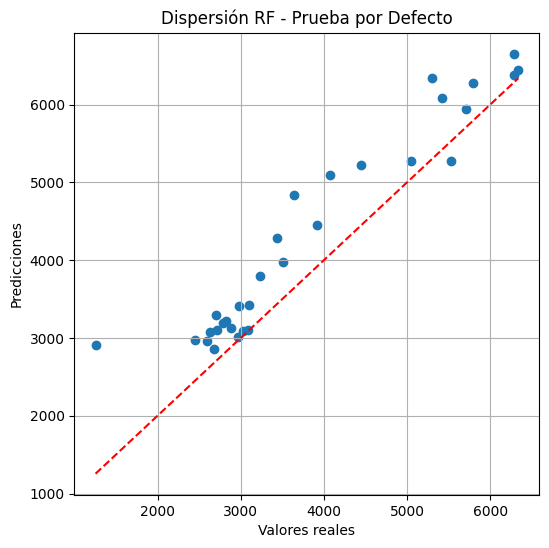

In [22]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf_default)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--')
plt.title("Dispersión RF - Prueba por Defecto")
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.grid(True)
plt.show()


PRUEBA 1 - Random Forest

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

tscv = TimeSeriesSplit(n_splits=5)

rf = RandomForestRegressor(random_state=42)

param_grid_rf_suave = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None]
}

grid_rf_suave = GridSearchCV(rf, param_grid_rf_suave, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_rf_suave.fit(X_train, y_train)

y_pred_rf_suave = grid_rf_suave.best_estimator_.predict(X_test)

mae_rf_suave = mean_absolute_error(y_test, y_pred_rf_suave)
mse_rf_suave = mean_squared_error(y_test, y_pred_rf_suave)
r2_rf_suave  = r2_score(y_test, y_pred_rf_suave)

mae_rf_suave, mse_rf_suave, r2_rf_suave, grid_rf_suave.best_params_


(486.77104174230783,
 377291.3639671135,
 0.7961812681566334,
 {'max_depth': 5, 'n_estimators': 100})

En la prueba 1 del Random Forest, donde se ajustaron parámetros moderados como n_estimators y max_depth, el rendimiento del modelo no mejoró frente al baseline inicial; por el contrario, el MAE aumentó (486.77) y el R² disminuyó (0.7961), lo que indica que los ajustes aplicados redujeron su capacidad de generalización. Esto demuestra que, para este problema temporal, el modelo por defecto estaba mejor configurado que las combinaciones más simples evaluadas; limitar la profundidad del árbol y usar menos árboles afectó negativamente la capacidad del modelo de capturar patrones semanales relevantes del dengue. Por este motivo es necesario aplicar una prueba 2, incrementando complejidad y explorando hiperparámetros más amplios, con el fin de buscar mejoras reales en el rendimiento predictivo.

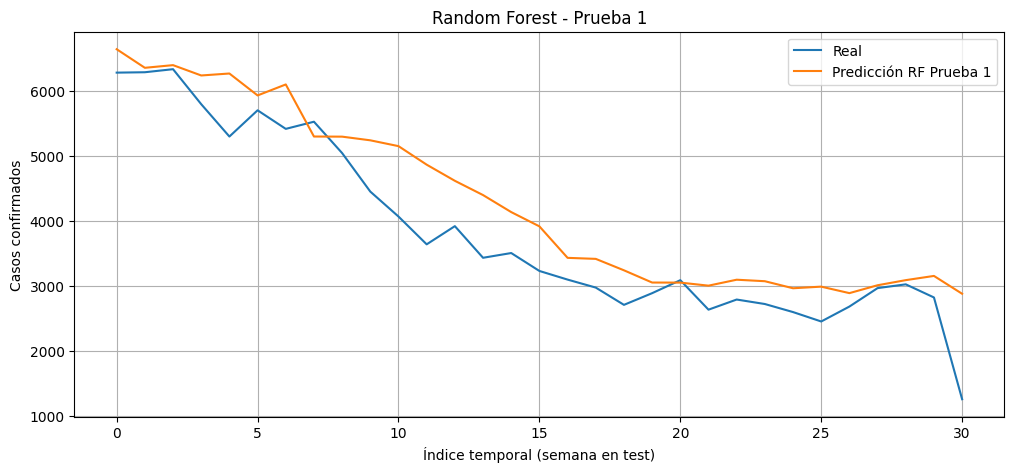

In [29]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Real")
plt.plot(y_pred_rf_suave, label="Predicción RF Prueba 1")
plt.title("Random Forest - Prueba 1")
plt.xlabel("Índice temporal (semana en test)")
plt.ylabel("Casos confirmados")
plt.legend()
plt.grid(True)
plt.show()


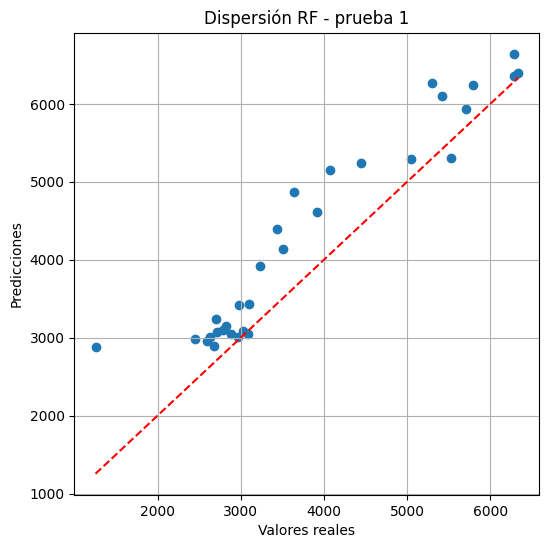

In [31]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf_suave)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--')
plt.title("Dispersión RF - prueba 1")
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.grid(True)
plt.show()


Prueba 2 - Random Forest

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

tscv = TimeSeriesSplit(n_splits=5)

rf = RandomForestRegressor(random_state=42)

param_grid_rf_agresivo = {
    'n_estimators':[300,500,700],
    'max_depth':[15,30,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'bootstrap':[True, False]
}

grid_rf_agresivo = GridSearchCV(rf, param_grid_rf_agresivo, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_rf_agresivo.fit(X_train, y_train)

y_pred_rf_agresivo = grid_rf_agresivo.best_estimator_.predict(X_test)

mae_rf_agresivo = mean_absolute_error(y_test, y_pred_rf_agresivo)
mse_rf_agresivo = mean_squared_error(y_test, y_pred_rf_agresivo)
r2_rf_agresivo = r2_score(y_test, y_pred_rf_agresivo)

mae_rf_agresivo, mse_rf_agresivo, r2_rf_agresivo, grid_rf_agresivo.best_params_


(449.66082181259605,
 329604.1462273581,
 0.8219426535820964,
 {'bootstrap': False,
  'max_depth': 15,
  'min_samples_leaf': 1,
  'min_samples_split': 5,
  'n_estimators': 700})

En la configuración de esta prueba, donde se exploraron mayor número de árboles, mayor profundidad y variaciones más amplias en los criterios de bootstrap y separación de muestras, el modelo logró mejorar su desempeño respecto al baseline por defecto. El MAE disminuyó a 449.66 (vs 482.11 baseline) y el R² aumentó ligeramente a 0.8219, mostrando un mayor ajuste y mejor capacidad predictiva del comportamiento semanal del dengue. El mejor modelo resultó ser aquel con profundidad de 15, 700 árboles, bootstrap desactivado, y mínimos splits más laxos, lo que evidencia que el modelo requiere mayor complejidad para capturar adecuadamente las variaciones temporales. Esto indica que Random Forest sí puede mejorar su desempeño si se incrementa sustancialmente su capacidad de aprendizaje, y demuestra que la manipulación agresiva de hiperparámetros puede generar ganancias reales de predicción en este problema epidemiológico.

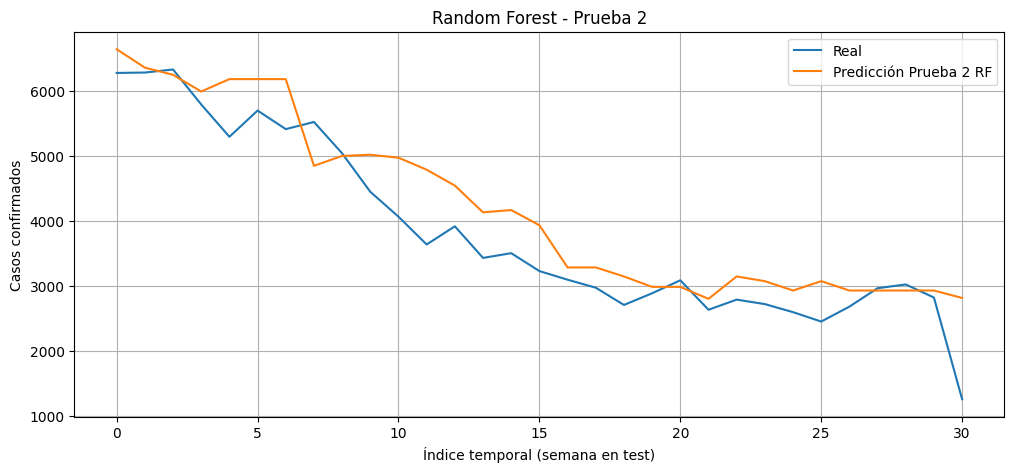

In [26]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Real")
plt.plot(y_pred_rf_agresivo, label="Predicción Prueba 2 RF")
plt.title("Random Forest - Prueba 2")
plt.xlabel("Índice temporal (semana en test)")
plt.ylabel("Casos confirmados")
plt.legend()
plt.grid(True)
plt.show()


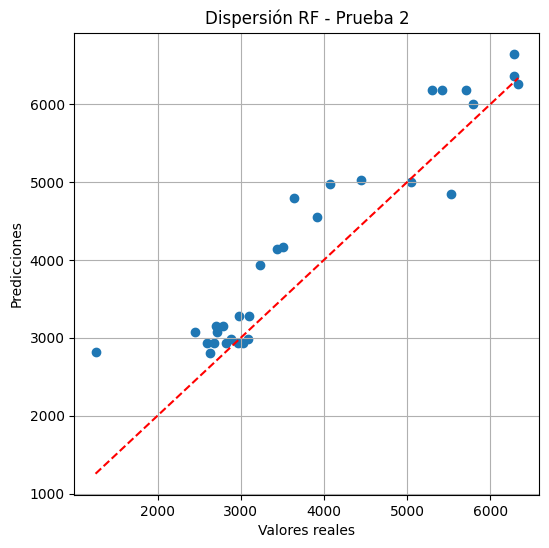

In [27]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf_agresivo)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--')
plt.title("Dispersión RF - Prueba 2")
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.grid(True)
plt.show()


Conclusión Final del Modelo Random Forest

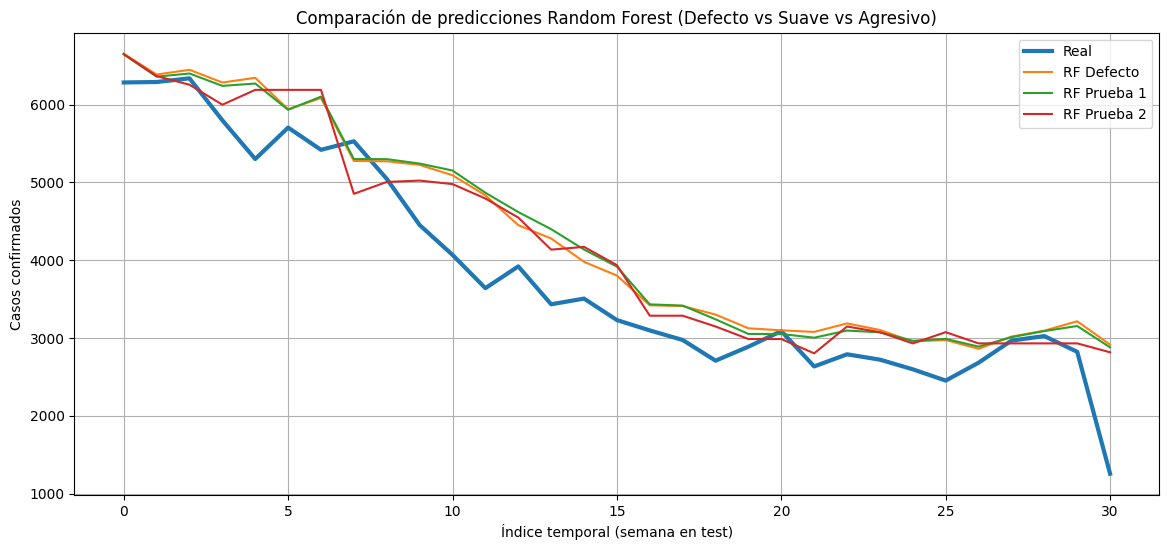

In [28]:
plt.figure(figsize=(14,6))
plt.plot(y_test.values, label="Real", linewidth=3)

plt.plot(y_pred_rf_default, label="RF Defecto")
plt.plot(y_pred_rf_suave, label="RF Prueba 1")
plt.plot(y_pred_rf_agresivo, label="RF Prueba 2")

plt.title("Comparación de predicciones Random Forest (Defecto vs Suave vs Agresivo)")
plt.xlabel("Índice temporal (semana en test)")
plt.ylabel("Casos confirmados")
plt.legend()
plt.grid(True)
plt.show()


El Random Forest mostró un rendimiento aceptable modelando la serie temporal semanal del dengue, con un nivel de ajuste considerable desde su configuración por defecto. Sin embargo, la manipulación de parámetros evidencia que el modelo necesita una mayor complejidad para mejorar. La prueba 1  empeoró las métricas, lo cual indica que reducir profundidad y número de árboles no es adecuado para este problema temporal. Por el contrario, la prueba 2 mejoró el MAE y elevó el R² respecto al baseline por defecto, demostrando que incrementar profundidad, número de árboles y modificar bootstrap permite capturar mejor las fluctuaciones del dengue.

Mejor versión del RF

La mejor prueba es numero 2, porque obtuvo el MAE más bajo y mejor capacidad predictiva. Por lo tanto, para la comparación final de modelos, se seleccionará Random Forest Tuning Agresivo como la versión oficial del modelo RF.

#### Modelo 4 — Red Neuronal MLP (Multi-Layer Perceptron)

Las redes neuronales tipo MLP (Multi-Layer Perceptron) son modelos de aprendizaje supervisado basados en capas densamente conectadas, donde cada neurona transforma la entrada mediante una función de activación no lineal. Estos modelos son adecuados para capturar relaciones no lineales entre los valores pasados de la serie temporal (lags, medias móviles y estacionalidad) y los casos futuros de dengue.

En este trabajo, el MLP se considera como una red neuronal “simple”, con pocas capas ocultas y una arquitectura relativamente compacta. Por este motivo, se analiza primero su desempeño como modelo base y posteriormente, mediante técnicas de optimización con GridSearchCV, se exploran configuraciones más adecuadas para este tipo de datos.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


##### Baseline — MLP por defecto

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mlp_default = MLPRegressor(random_state=42, max_iter=2000)
mlp_default.fit(X_train_scaled, y_train)
y_pred_mlp_default = mlp_default.predict(X_test_scaled)

mae_mlp_default = mean_absolute_error(y_test, y_pred_mlp_default)
mse_mlp_default = mean_squared_error(y_test, y_pred_mlp_default)
r2_mlp_default  = r2_score(y_test, y_pred_mlp_default)

mae_mlp_default, mse_mlp_default, r2_mlp_default


In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Real")
plt.plot(y_pred_mlp_default, label="Predicción MLP Defecto")
plt.title("MLP - Prueba por defecto")
plt.xlabel("Semana en test")
plt.ylabel("Casos confirmados")
plt.legend()
plt.grid(True)
plt.show()


##### Prueba 1 - MLP

In [ ]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

mlp = MLPRegressor(max_iter=2500, random_state=42)

param_grid_mlp = {
    'hidden_layer_sizes': [(32,), (64,), (32,16)],
    'alpha': [0.0001, 0.001]
}

grid_mlp = GridSearchCV(
    mlp,
    param_grid_mlp,
    cv=tscv,
    scoring='neg_mean_absolute_error'
)

grid_mlp.fit(X_train_scaled, y_train)
y_pred_mlp_suave = grid_mlp.best_estimator_.predict(X_test_scaled)

mae_mlp_suave = mean_absolute_error(y_test, y_pred_mlp_suave)
mse_mlp_suave = mean_squared_error(y_test, y_pred_mlp_suave)
r2_mlp_suave  = r2_score(y_test, y_pred_mlp_suave)

mae_mlp_suave, mse_mlp_suave, r2_mlp_suave, grid_mlp.best_params_


##### Prueba 2 — MLP

In [ ]:
param_grid_mlp= {
    'hidden_layer_sizes': [
        (64,32),
        (128,64),
        (100,100),
    ],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant','adaptive']
}

mlp2 = MLPRegressor(max_iter=4000, random_state=42)

grid_mlp = GridSearchCV(
    mlp2,
    param_grid_mlp,
    cv=tscv,
    scoring='neg_mean_absolute_error'
)

grid_mlp.fit(X_train_scaled, y_train)
y_pred_mlp_agresivo = grid_mlp.best_estimator_.predict(X_test_scaled)

mae_mlp_agresivo = mean_absolute_error(y_test, y_pred_mlp_agresivo)
mse_mlp_agresivo = mean_squared_error(y_test, y_pred_mlp_agresivo)
r2_mlp_agresivo  = r2_score(y_test, y_pred_mlp_agresivo)

mae_mlp_agresivo, mse_mlp_agresivo, r2_mlp_agresivo, grid_mlp.best_params_
